In [24]:
import time
from io import BytesIO
from datetime import datetime, UTC, timedelta
import traceback
import json
import io
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from werkzeug.exceptions import BadRequest
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import statistics

#from app.helpers.fold_storage_manager import FoldStorageManager
from app.helpers.sequence_util import (
    get_measured_and_unmeasured_mutant_seq_ids,
    get_loci_set,
    process_and_validate_evolve_input_files,
)




def train_model(wt_aa_seq,raw_activity_df,raw_embedding_df,model):
    """
    Train a machine learning model on protein sequence data.
    
    Args:
        wt_aa_seq: Wild-type amino acid sequence
        raw_activity_df: DataFrame containing activity measurements
        raw_embedding_df: DataFrame containing protein embeddings
        model: Machine learning model instance
        
    Returns:
        DataFrame with predicted activities
    """
    activity_df, embedding_df = process_and_validate_evolve_input_files(
                wt_aa_seq, raw_activity_df, raw_embedding_df
            )
    measured_mutants, unmeasured_mutants = (
                get_measured_and_unmeasured_mutant_seq_ids(activity_df, embedding_df)
            )
    X_train = np.vstack(
                [json.loads(x) for x in embedding_df.loc[activity_df.index].embedding]
            )
    y_train = activity_df.activity.to_numpy()
    
    model.fit(X_train, y_train)
    try:
        all_mutants_embedding_array = np.vstack(
            [
                json.loads(x)
                for x in embedding_df.loc[
                    measured_mutants + unmeasured_mutants
                ].embedding
            ]
        )
        #print(all_mutants_embedding_array.shape)
        y_all_pred = model.predict(all_mutants_embedding_array)
        predicted_activity_df = pd.DataFrame(
            {
                "seq_id": measured_mutants + unmeasured_mutants,
                "predicted_activity": y_all_pred,
            }
        )
        predicted_activity_df.index = predicted_activity_df.seq_id
        predicted_activity_df["relevant_measured_mutants"] = (
            predicted_activity_df.seq_id.apply(
                lambda seq_id: " ".join(
                    [
                        m
                        for m in measured_mutants
                        if get_loci_set(m) & get_loci_set(seq_id)
                    ]
                )
            )
        )
        predicted_activity_df["actual_activity"] = predicted_activity_df.join(
            activity_df.groupby(level=0).activity.mean(), how="left"
        ).activity
        predicted_activity_df = predicted_activity_df.sort_values(
            "predicted_activity", ascending=False
        )
    except Exception as e:
        print(f"Failed to predict activities: {e}")
        raise
    predicted_activity_df.reset_index(drop=True,inplace=True)
    #predicted_activity_csv_path = evolve_directory / f"Round_{round_num}_predicted_activity.csv"
    #print(f"Storing predicted activities in {predicted_activity_csv_path}")
    #try:
    #    predicted_activity_df.to_csv(predicted_activity_csv_path, index=False)
    #except Exception as e:
    #    print(f"Failed to store predicted activities: {e}")
    #    raise
    return predicted_activity_df

def evaluate_predictions(predicted_activity_df,exp_activity_df,round_activity_df,num_var,round_num,evolve_directory):
    """
    Evaluate model predictions and select top variants.
    
    Args:
        predicted_activity_df: DataFrame with model predictions
        exp_activity_df: DataFrame with experimental activities
        round_activity_df: DataFrame with current round activities
        num_var: Number of variants to select
        round_num: Current round number
        evolve_directory: Directory to save results
        
    Returns:
        DataFrame with next round activities
    """
    try:
        predict = predicted_activity_df["actual_activity"].isna()
        extract_predict = predicted_activity_df[predict]
        #print(extract_predict)
        top_var = extract_predict.iloc[0:num_var]
        #print(top_var)
        top_var_real = pd.merge(top_var,exp_activity_df,on='seq_id', how='inner')
        top_var_real = top_var_real[['seq_id','activity']]
        #top_var_csv_path = evolve_directory / f"Round_{round_num}_top_variants.xlsx"
        #top_var_real.to_excel(top_var_csv_path, index=False)
        next_round_activity = pd.concat([round_activity_df,top_var_real], ignore_index=True)
    except Exception as e:
        print(f"Failed to Evaluate Predictions")
        raise
    return next_round_activity

def evolve_simulation(wt_aa_seq,embeddings_path,exp_activity_file_path,num_var,model_type,quantile):
    """
    Run evolutionary optimization simulation.
    
    Args:
        wt_aa_seq: Wild-type amino acid sequence
        embeddings_path: Path to embeddings file
        exp_activity_file_path: Path to experimental activity file
        num_var: Number of variants per round
        model_type: Machine learning model to use
        quantile: Quantile threshold for top variants
        
    Returns:
        tuple: (num_rounds, list of top variants per round)
    """
    try:
        # Df generation
        exp_activity_df = pd.read_excel(exp_activity_file_path)
        raw_embedding_df = pd.read_csv(embeddings_path)
        raw_activity_df = exp_activity_df.sample(num_var)
        while not raw_activity_df['seq_id'].isin(raw_embedding_df['seq_id']).all():
            raw_activity_df = exp_activity_df.sample(num_var)
        #print(raw_activity_df)
        evolve_directory = Path("evolve") / Path(exp_activity_file_path).stem
        evolve_directory.mkdir(parents=True, exist_ok=True)
        #init_var_path = evolve_directory / f"Round_0_variants.xlsx"
        #raw_activity_df.to_excel(init_var_path, index=False)
        var_exp_data = [raw_activity_df.sort_values('activity',ascending=True)]
        #top_percent_df = exp_activity_df.sort_values('activity',ascending=False)
        #print(top_percent_df)
        #print('this is the sorted activity')
        top_percent_activity = exp_activity_df['activity'].quantile(quantile)
        top_percent_df = exp_activity_df[exp_activity_df['activity'] >= top_percent_activity]
        #print('There are this many top variants')
        #print(top_percent_df.shape)
        #print(f'These are the top variants')
        #print(top_percent_df)
        #print(round(len(top_percent_df)*0.51))
        i = 1
        complete = True
        top_var_per_round = []
        while complete:
            if i == 1:
                predicted_activity_df = train_model(wt_aa_seq,raw_activity_df,raw_embedding_df,model_type)
                current_round_activity_df = evaluate_predictions(predicted_activity_df,exp_activity_df,raw_activity_df,num_var,i,evolve_directory)
                #print(i)
                #print(current_round_activity_df)
            else:
                predicted_activity_df = train_model(wt_aa_seq,current_round_activity_df,raw_embedding_df,model_type)
                current_round_activity_df = evaluate_predictions(predicted_activity_df,exp_activity_df,current_round_activity_df,num_var,i,evolve_directory)
                #print(i)
                #print(top_percent_df['seq_id'].isin(current_round_activity_df['seq_id']).all())
            var_exp_data.append(current_round_activity_df.sort_values('activity',ascending=True))
            #if i == round_num:
            #    complete = False
            #    break
            num_top_var_df = pd.merge(top_percent_df,current_round_activity_df, on='seq_id')
            top_var_per_round.append(len(num_top_var_df))
            if len(num_top_var_df) >= (round(len(top_percent_df)*.2)):
                print('test')
                complete = False
                break  
            print(f'Round {i} Evolution found {len(num_top_var_df)} top variants')
            i += 1
            #print(current_round_activity_df.shape)


        print(f'It took {i} rounds to get the majority of the top {quantile * 100} % of variants')
        print(top_var_per_round)
        #print(var_exp_data)
        return i, top_var_per_round
    except Exception as e:
        print(f"Evolution simulation failed: {str(e)}")
        traceback.print_exc()
        raise
def plot_evolution(evo_imgs, embeddings_paths, figsize=(14, 5), colors=None):
    """
    Plot evolution results for multiple embedding models.
    
    Args:
        evo_imgs: List of (means, std_errors) tuples for each model
        embeddings_paths: List of embedding model names/paths
        figsize: Figure size tuple
        colors: Optional list of colors for bars
    """
    if colors is None:
        colors = plt.cm.tab20(np.linspace(0, 1, len(evo_imgs)))
        
    num_imgs = len(evo_imgs)
    num_cols = 2
    num_rows = (num_imgs + num_cols - 1) // num_cols
    
    fig, axes = plt.subplots(num_rows, num_cols, 
                            figsize=(figsize[0], figsize[1] * num_rows))
    axes = np.array(axes).reshape(-1)
    
    max_y_value = max(max(means) + max(std_errors) 
                     for means, std_errors in evo_imgs)
    
    for i, ((means, std_errors), label, color) in enumerate(zip(evo_imgs, 
                                                              embeddings_paths,
                                                              colors)):
        ax = axes[i]
        x_indices = np.arange(1, len(means) + 1)
        
        ax.bar(x_indices, means, yerr=std_errors, 
               capsize=5, label=label, color=color, 
               edgecolor='black')
        
        ax.set_xlabel('Rounds')
        ax.set_ylabel('Top Variants')
        ax.set_title(f'Embedding Model: {label}')
        ax.set_xticks(x_indices)
        ax.set_xticklabels([f'Round {k}' for k in x_indices])
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.set_ylim(0, max_y_value * 1.1)
    
    for j in range(num_imgs, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()

def plot_evolution_line(evo_imgs, embeddings_paths, figsize=(14, 5), colors=None, markersize=8):
    """
    Plot evolution results for multiple embedding models on the same graph.
    
    Args:
        evo_imgs: List of (means, std_errors) tuples for each model
        embeddings_paths: List of embedding model names/paths
        figsize: Figure size tuple
        colors: Optional list of colors for bars
        
    Returns:
        fig: Matplotlib figure object
    """
    if not evo_imgs or not embeddings_paths:
        raise ValueError("evo_imgs and embeddings_paths must not be empty")
    
    if len(evo_imgs) != len(embeddings_paths):
        raise ValueError("evo_imgs and embeddings_paths must have the same length")
    
    if colors is None:
        colors = plt.cm.tab20(np.linspace(0, 1, len(evo_imgs)))
        
    fig, ax = plt.subplots(figsize=figsize)
    
    max_y_value = 0
    
    for i, ((means, std_errors), label, color) in enumerate(zip(evo_imgs, embeddings_paths, colors)):
        x_indices = np.arange(1, len(means) + 1)
        
        ax.errorbar(x_indices, means, yerr=std_errors, capsize=5, label=label, color=color, marker='o', linestyle='-',markersize=markersize)
        
        # Update max_y_value for setting y-axis limit
        max_y_value = max(max_y_value, max(means) + max(std_errors))
    
    ax.set_xlabel('Rounds')
    ax.set_ylabel('Top Variants')
    ax.set_title('Evolution Results for Multiple Embedding Models')
    ax.set_xticks(x_indices)
    ax.set_xticklabels([f'Round {k}' for k in x_indices])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, max_y_value * 1.1)
    
    plt.tight_layout()


In [5]:
randomforest = RandomForestRegressor(
        n_estimators=100,
        criterion="friedman_mse",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features=1.0,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=False,
        n_jobs=None,
        random_state=1,
        verbose=0,
        warm_start=False,
        ccp_alpha=0.0,
        max_samples=None,
    )


In [6]:
embeddings_dir = '../EvolveTest'
embeddings_paths = ['kelsic_esmc_600m_wt_dms']
embeddings_path = os.path.join(embeddings_dir, embeddings_paths[0])
print(embeddings_path)

../EvolveTest\kelsic_esmc_600m_wt_dms


In [ ]:
import os
from datetime import date, time
wt_aa_seq = 'MAKEDNIEMQGTVLETLPNTMFRVELENGHVVTAHISGKMRKNYIRILTGDKVTVELTPYDLSKGRIVFRSR'
dataset = 'kelsic'
exp_activity_file_path = r'..\EvolveTest\Kelsic_Data_foldy.xlsx'
embeddings_dir = '../EvolveTest'
embeddings_paths = [
    'kelsic_esm1b_t33_650M_UR50S.csv',
    'kelsic_esm2_t33_650M_UR50D.csv',
    'kelsic_esm2_t36_3B_UR50D.csv',
    'kelsic_esmc_600m_wt_dms.csv'
]
model_type = randomforest
quantile = 0.9
rounds_evo = 2
num_var = 20
embeddings_rounds_to_top = {}
evo_imgs = []
for path in embeddings_paths:

    embeddings_path = os.path.join(embeddings_dir, path)
    round_to_best = []
    var_per_round = []

    for j in range(rounds_evo):

        rounds, var_sum = evolve_simulation(wt_aa_seq,embeddings_path,exp_activity_file_path,num_var,model_type,quantile)
        round_to_best.append(rounds)
        var_per_round.append(var_sum)

    avg_round = statistics.mean(round_to_best)
    vars_per_round = [np.array(x) for x in var_per_round]
    avg_var_per_round = []
    std_error_per_round = []

    for k in zip(*vars_per_round):
        avg = np.mean(k)
        std_dev = np.std(k, ddof=1)
        se = std_dev / np.sqrt(len(k))
        avg_var_per_round.append(float(avg))
        std_error_per_round.append(float(se))

    embeddings_rounds_to_top[path] = [avg_round,avg_var_per_round]
    print(avg_round)
    print(avg_var_per_round)
    evo_imgs.append([avg_var_per_round,std_error_per_round])
    
print(evo_imgs)
    
embeddings_comp_df = pd.DataFrame.from_dict(embeddings_rounds_to_top, orient='index',columns=['Median Round','Total Variants per Round'])
evolve_path = os.path.join(embeddings_dir,dataset)
try:
    os.mkdir(evolve_path)
except OSError as error:
    print(error)
comp_dir = os.path.join(embeddings_dir, dataset, f'{date.today()}{num_var}Variant_Model_Comparisons_{quantile}.xlsx')
embeddings_comp_df.to_excel(comp_dir, index=True)






Round 1 Evolution found 13 top variants
Round 2 Evolution found 19 top variants
Round 3 Evolution found 24 top variants
Round 4 Evolution found 27 top variants
Round 5 Evolution found 35 top variants
Round 6 Evolution found 45 top variants
Round 7 Evolution found 53 top variants
test
It took 8 rounds to get the majority of the top 80.0 % of variants
[13, 19, 24, 27, 35, 45, 53, 61]
Round 1 Evolution found 9 top variants
Round 2 Evolution found 18 top variants
Round 3 Evolution found 26 top variants
Round 4 Evolution found 33 top variants
Round 5 Evolution found 43 top variants
Round 6 Evolution found 51 top variants
test
It took 7 rounds to get the majority of the top 80.0 % of variants
[9, 18, 26, 33, 43, 51, 62]
7.5
[11.0, 18.5, 25.0, 30.0, 39.0, 48.0, 57.5]
Round 1 Evolution found 14 top variants
Round 2 Evolution found 29 top variants
Round 3 Evolution found 34 top variants
Round 4 Evolution found 41 top variants
Round 5 Evolution found 50 top variants
Round 6 Evolution found 54 to

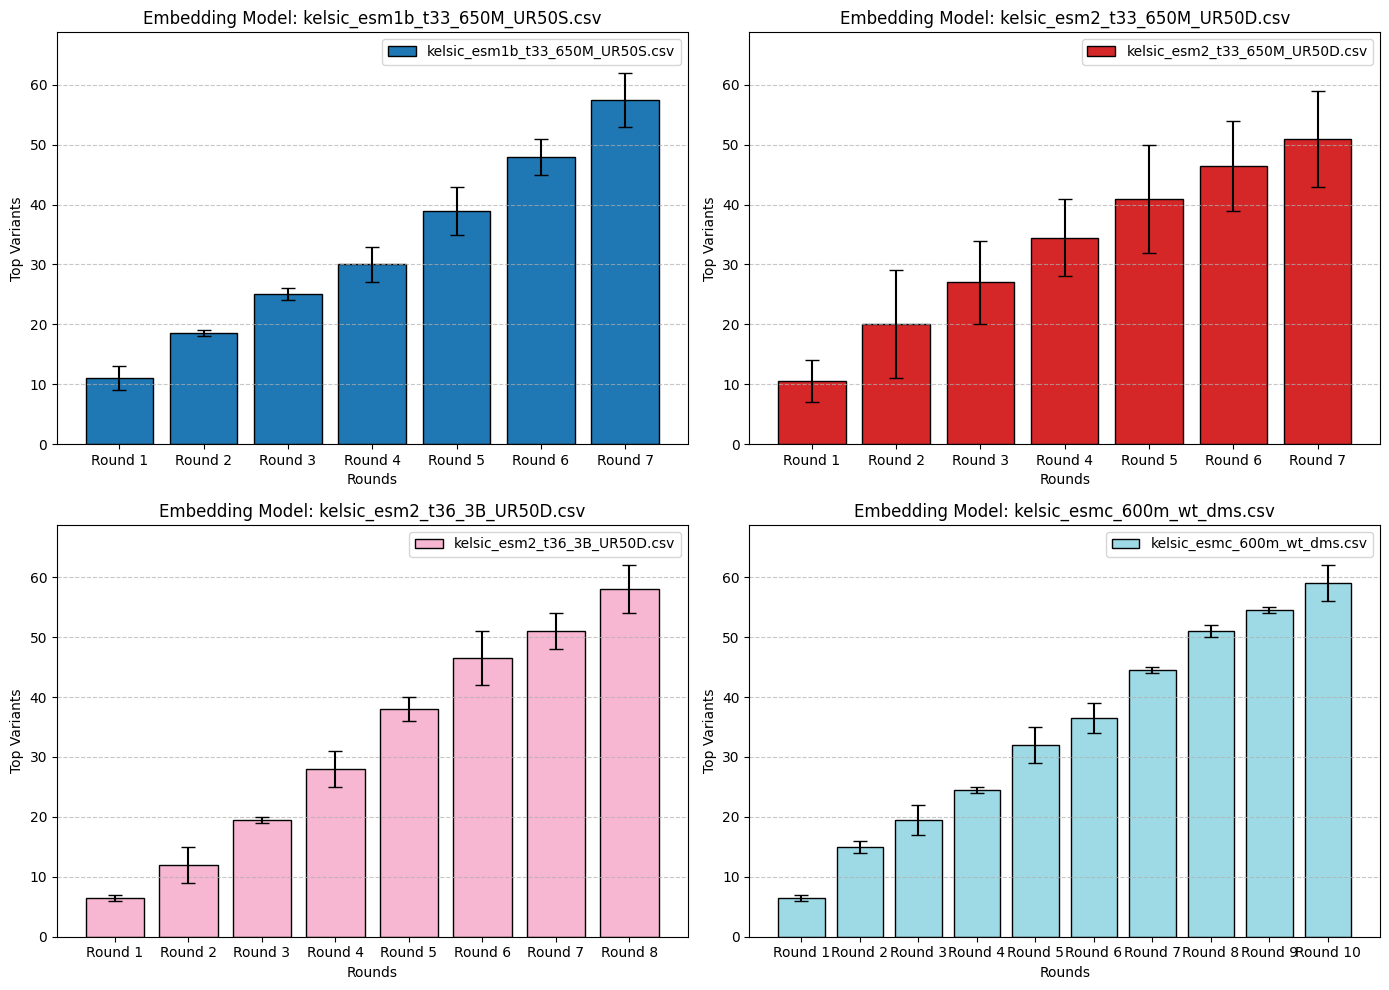

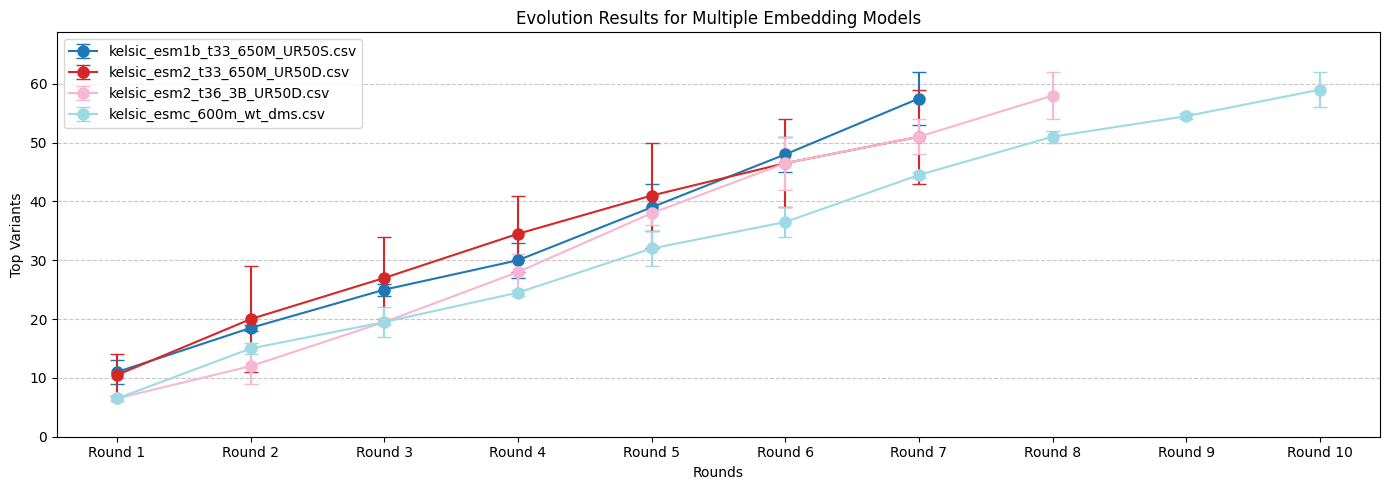

In [25]:
plot_evolution(evo_imgs, embeddings_paths)
plot_evolution_line(evo_imgs, embeddings_paths)